# MICrONS20 recurrent network

This experiment uses the validated 20-neuron structural SONATA circuit and activates the 54 observed recurrent contacts.

The anatomical information is retained from MICrONS:

- selected neuron identities;
- processed CAVE-derived morphologies;
- source and target neuron identities;
- individual synapse IDs;
- postsynaptic section IDs and section positions.

The membrane and synaptic parameters are modelling assumptions for this first connected simulation. They are not fitted to the MICrONS functional recordings.


In [1]:
from microns20.config import find_project_root
from microns20.recurrent_simulation import (
    compile_recurrent_mechanisms,
    plot_recurrent_spike_raster,
    plot_source_and_target_voltage,
    prepare_recurrent_run,
    run_recurrent_network,
    save_recurrent_summary,
    summarize_recurrent_run,
    validate_recurrent_experiment_assets,
)

project_root = find_project_root()
project_root


PosixPath('<PROJECT_ROOT>')

## 1. Validate the structural circuit and modelling inputs

The structural edge HDF5 file is checked against `intrinsic_synapses.parquet` before any simulation-specific type table is created.


In [2]:
audit = validate_recurrent_experiment_assets(project_root)

print("Selected neurons:", audit["n_cells"])
print("Intrinsic anatomical contacts:", audit["n_intrinsic_contacts"])
print("Directed recurrent pairs:", audit["n_directed_pairs"])
print("Selected stimulation source:", audit["source_model_node_id"])
print("Direct recurrent targets:", len(audit["direct_targets"]))
print("Axon-target contacts:", audit["n_axon_target_contacts"])

print("\nReference synapse parameters:")
print(audit["synapse_parameters"])

display(audit["source_ranking"])
display(audit["direct_targets"])
display(audit["section_summary"])


Selected neurons: 20
Intrinsic anatomical contacts: 54
Directed recurrent pairs: 38
Selected stimulation source: 13
Direct recurrent targets: 5
Axon-target contacts: 2

Reference synapse parameters:
{'level_of_detail': 'exp2syn', 'tau1': 0.2, 'tau2': 1.8, 'erev': 0.0}


,source_rank,model_node_id,nucleus_id,pt_root_id,microns_mtype,n_distinct_targets,n_outgoing_contacts,selected_for_stimulation
0,1,13,296513,864691135385310443,L4a,5,9,True
1,2,16,296779,864691135361231448,L4a,4,7,False
2,3,8,262698,864691135294441654,L4b,4,4,False
3,4,0,260303,864691136275332030,L4a,3,4,False
4,5,3,260628,864691135375888840,L4a,3,4,False
5,6,17,298916,864691135577816862,L4b,2,4,False
6,7,4,260648,864691136336274867,L4b,2,3,False
7,8,5,260689,864691137022275182,L4b,2,3,False
8,9,9,262810,864691135369693945,L4b,2,3,False
9,10,1,260621,864691135563052513,L4b,2,2,False


,model_node_id,n_contacts_from_source
0,0,2
1,5,1
2,6,4
3,12,1
4,18,1


,afferent_section_type,target_compartment,n_contacts
0,2,axon,2
1,3,dendrite,52


## 2. Prepare the connected BioNet experiment

The validated structural SONATA files remain unchanged in `data/processed/sonata/`.

This cell creates a separate run under `runs/microns20_recurrent/`. The selected-node and intrinsic-edge HDF5 files are copied unchanged. Only the run-specific type tables add cell and synapse model parameters.


In [4]:
run_info = prepare_recurrent_run(
    project_root,
    overwrite=True,
)

{
    key: value
    for key, value in run_info.items()
    if key
    not in {
        "manifest",
        "intrinsic_synapses",
        "source_ranking",
        "direct_targets",
        "section_summary",
    }
}


{'selected_population': 'microns20',
 'intrinsic_population': 'microns20_to_microns20',
 'selected_nodes': PosixPath('<PROJECT_ROOT>/data/processed/sonata/network/nodes/microns20_nodes.h5'),
 'selected_types': PosixPath('<PROJECT_ROOT>/data/processed/sonata/network/nodes/microns20_node_types.csv'),
 'intrinsic_edges': PosixPath('<PROJECT_ROOT>/data/processed/sonata/network/edges/microns20_to_microns20_edges.h5'),
 'intrinsic_types': PosixPath('<PROJECT_ROOT>/data/processed/sonata/network/edges/microns20_to_microns20_edge_types.csv'),
 'structural_morphologies': PosixPath('<PROJECT_ROOT>/data/processed/sonata/components/morphologies'),
 'n_cells': 20,
 'n_intrinsic_contacts': 54,
 'n_directed_pairs': 38,
 'source_model_node_id': 13,
 'n_axon_target_contacts': 2,
 'allen_source_dir': PosixPath('<PROJECT_ROOT>/data/external/allen_cell_types/487245719'),
 'cell_dynamics_file': PosixPath('<PROJECT_ROOT>/data/external/allen_cell_types/487245719/fit_parameters.json'),
 'n_modfiles': 16,
 'cel

In [7]:
import pandas as pd

node_types = pd.read_csv(
    run_info["network_dir"]
    / "microns20_node_types.csv",
    sep=r"\s+",
)

display(
    node_types[
        [
            "node_type_id",
            "morphology",
            "model_type",
            "model_processing",
            "recenter",
        ]
    ]
)

print("Rows:", len(node_types))
print(
    "Any bytes-style names:",
    node_types["morphology"]
    .astype(str)
    .str.startswith("b'")
    .any(),
)

from pathlib import Path

morphology_dir = (
    run_info["components_dir"]
    / "morphologies"
)

files = sorted(
    morphology_dir.glob("*.swc")
)

print("Morphologies:", len(files))
print(files[0])
print(files[-1])

,node_type_id,morphology,model_type,model_processing,recenter
0,0,model_000_nucleus_260303_root_8646911362753320...,biophysical,microns_perisomatic_preserve_morphology,0
1,1,model_001_nucleus_260621_root_8646911355630525...,biophysical,microns_perisomatic_preserve_morphology,0
2,2,model_002_nucleus_260625_root_8646911360432830...,biophysical,microns_perisomatic_preserve_morphology,0
3,3,model_003_nucleus_260628_root_8646911353758888...,biophysical,microns_perisomatic_preserve_morphology,0
4,4,model_004_nucleus_260648_root_8646911363362748...,biophysical,microns_perisomatic_preserve_morphology,0
5,5,model_005_nucleus_260689_root_8646911370222751...,biophysical,microns_perisomatic_preserve_morphology,0
6,6,model_006_nucleus_262547_root_8646911353758957...,biophysical,microns_perisomatic_preserve_morphology,0
7,7,model_007_nucleus_262654_root_8646911357833227...,biophysical,microns_perisomatic_preserve_morphology,0
8,8,model_008_nucleus_262698_root_8646911352944416...,biophysical,microns_perisomatic_preserve_morphology,0
9,9,model_009_nucleus_262810_root_8646911353696939...,biophysical,microns_perisomatic_preserve_morphology,0


Rows: 20
Any bytes-style names: False
Morphologies: 20
<PROJECT_ROOT>/runs/microns20_recurrent/components/morphologies/model_000_nucleus_260303_root_864691136275332030.swc
<PROJECT_ROOT>/runs/microns20_recurrent/components/morphologies/model_019_nucleus_299068_root_864691135481148614.swc


## 3. Compile the cell-model mechanisms


In [8]:
mechanism_library = compile_recurrent_mechanisms(run_info)
mechanism_library


PosixPath('<PROJECT_ROOT>/runs/microns20_recurrent/components/mechanisms/x86_64/libnrnmech.so')

## 4. Run the recurrent network

Only the automatically selected source neuron receives the somatic current step. The other 19 neurons receive no direct current injection.

Any response in those neurons therefore arises through the recurrent contacts represented in this experiment.


In [9]:
output_dir = run_recurrent_network(run_info)
output_dir


2026-08-26 14:08:03,760 [INFO] Created log file


INFO:NEURONIOUtils:Created log file


2026-08-26 14:08:03,853 [INFO] Building cells.


INFO:NEURONIOUtils:Building cells.


2026-08-26 14:08:05,846 [INFO] Building recurrent connections


...

2026-08-26 14:08:10,070 [INFO]     step:10000 t_sim:1000.00 ms


INFO:NEURONIOUtils:    step:10000 t_sim:1000.00 ms


2026-08-26 14:08:10,098 [INFO] Simulation completed in 4.167 seconds 


INFO:NEURONIOUtils:Simulation completed in 4.167 seconds 


PosixPath('<PROJECT_ROOT>/runs/microns20_recurrent/output')

## 5. Summarize the network response

In [10]:
summary = summarize_recurrent_run(run_info)

display(summary)

summary_path = save_recurrent_summary(
    run_info,
    summary,
)

summary_path


,model_node_id,nucleus_id,microns_mtype,network_role,n_contacts_from_source,simulation_success,baseline_vm_mean_mv,analysis_peak_vm_mv,max_depolarization_mv,spike_count,first_spike_time_ms
0,0,260303,L4a,direct_target,2,True,-84.626482,-83.466854,1.159628,0,NaN
1,1,260621,L4b,other,0,True,-84.626833,-84.626462,0.000371,0,NaN
2,2,260625,L4b,other,0,True,-84.633118,-84.632530,0.000588,0,NaN
3,3,260628,L4a,other,0,True,-84.633351,-84.632732,0.000619,0,NaN
4,4,260648,L4b,other,0,True,-84.629894,-84.629440,0.000454,0,NaN
5,5,260689,L4b,direct_target,1,True,-84.630553,-83.877545,0.753009,0,NaN
6,6,262547,L4a,direct_target,4,True,-84.634166,-81.781162,2.853004,0,NaN
7,7,262654,L4b,other,0,True,-84.636531,-84.635811,0.000720,0,NaN
8,8,262698,L4b,other,0,True,-84.632464,-84.631942,0.000521,0,NaN
9,9,262810,L4b,other,0,True,-84.630525,-84.630043,0.000482,0,NaN


PosixPath('<PROJECT_ROOT>/runs/microns20_recurrent/network_response_summary.csv')

In [11]:
source_id = run_info["source_model_node_id"]

print(
    "Finite voltage traces:",
    int(summary["simulation_success"].sum()),
    "/",
    len(summary),
)

print(
    "Stimulated source:",
    source_id,
)

print(
    "Direct targets:",
    int(summary["network_role"].eq("direct_target").sum()),
)

print(
    "Unstimulated cells with spikes in the analysis window:",
    int(
        summary.loc[
            summary["model_node_id"].ne(source_id),
            "spike_count",
        ].gt(0).sum()
    ),
)

display(
    summary.sort_values(
        [
            "network_role",
            "max_depolarization_mv",
        ],
        ascending=[True, False],
    )
)


Finite voltage traces: 20 / 20
Stimulated source: 13
Direct targets: 5
Unstimulated cells with spikes in the analysis window: 0


,model_node_id,nucleus_id,microns_mtype,network_role,n_contacts_from_source,simulation_success,baseline_vm_mean_mv,analysis_peak_vm_mv,max_depolarization_mv,spike_count,first_spike_time_ms
6,6,262547,L4a,direct_target,4,True,-84.634166,-81.781162,2.853004,0,NaN
0,0,260303,L4a,direct_target,2,True,-84.626482,-83.466854,1.159628,0,NaN
5,5,260689,L4b,direct_target,1,True,-84.630553,-83.877545,0.753009,0,NaN
12,12,296508,L4a,direct_target,1,True,-84.628883,-83.881477,0.747406,0,NaN
18,18,299060,L4a,direct_target,1,True,-84.632216,-83.989325,0.642891,0,NaN
10,10,262892,L4b,other,0,True,-84.642173,-84.641091,0.001082,0,NaN
14,14,296680,L4b,other,0,True,-84.638293,-84.637464,0.000828,0,NaN
7,7,262654,L4b,other,0,True,-84.636531,-84.635811,0.000720,0,NaN
3,3,260628,L4a,other,0,True,-84.633351,-84.632732,0.000619,0,NaN
2,2,260625,L4b,other,0,True,-84.633118,-84.632530,0.000588,0,NaN


## 6. Network spike raster

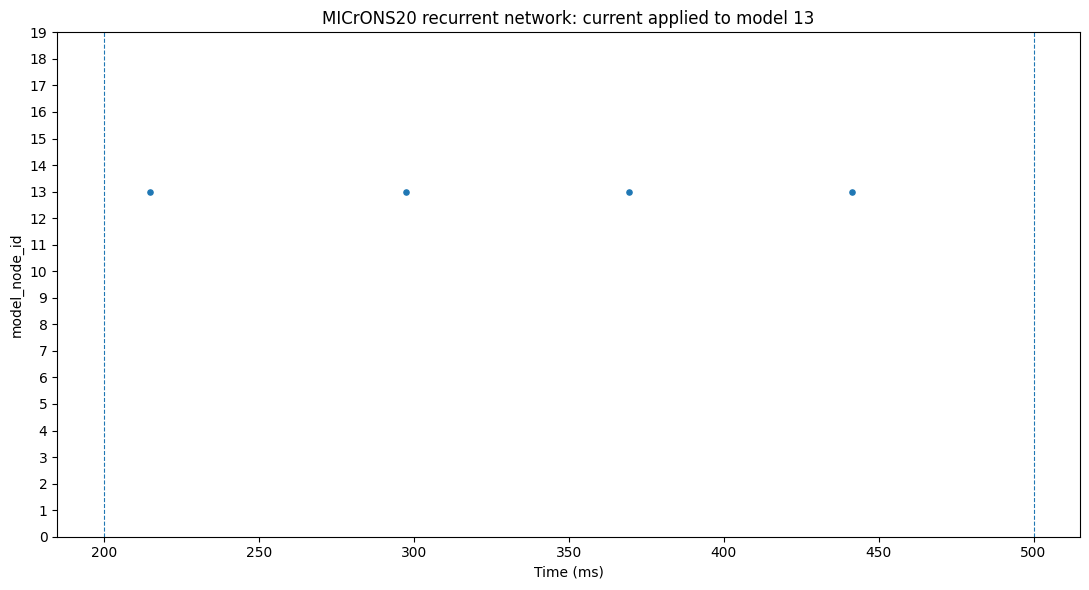

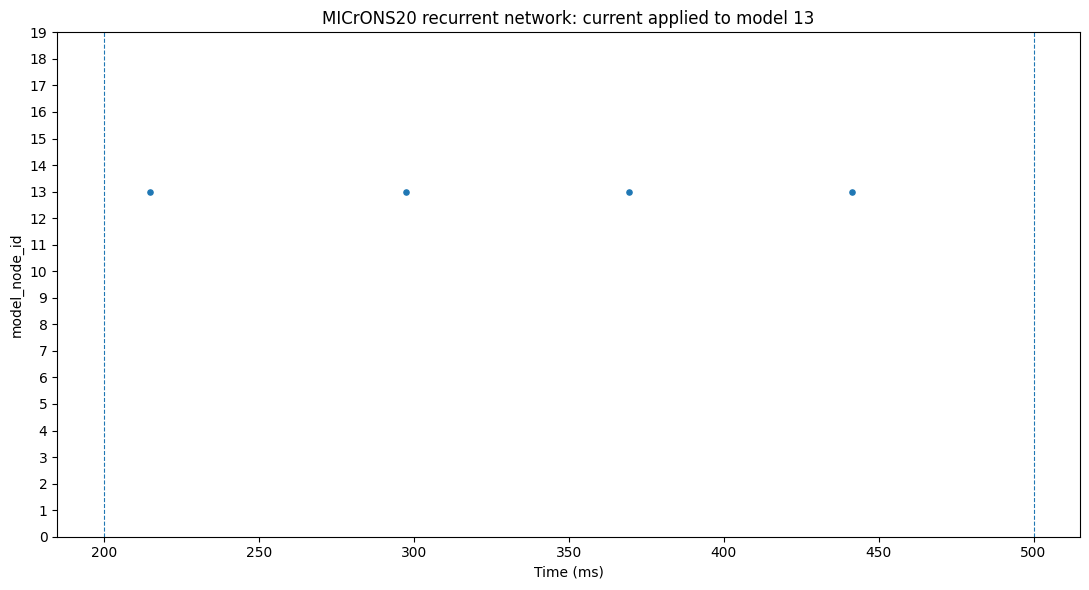

In [12]:
plot_recurrent_spike_raster(run_info)


## 7. Stimulated neuron and direct postsynaptic targets

Direct targets may show only subthreshold EPSPs. A lack of postsynaptic spikes is not a failed simulation and should not be corrected by increasing the synaptic weight simply to force propagation.


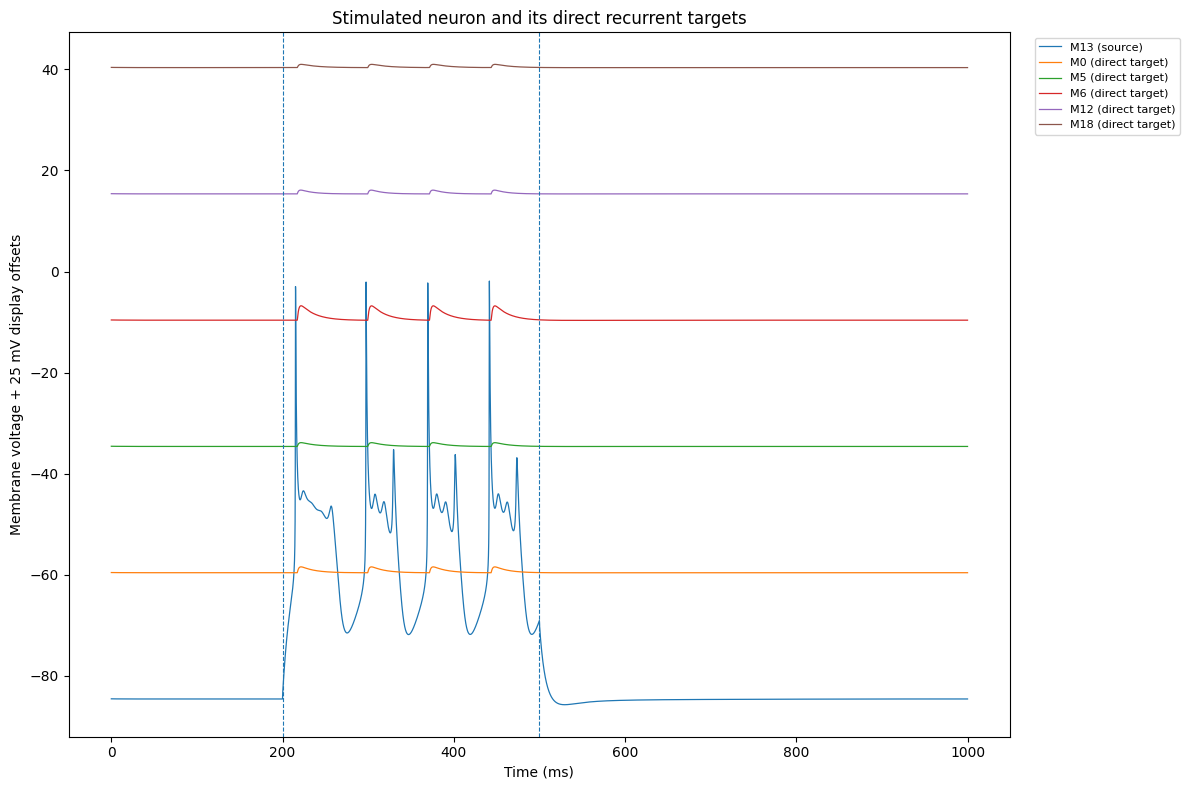

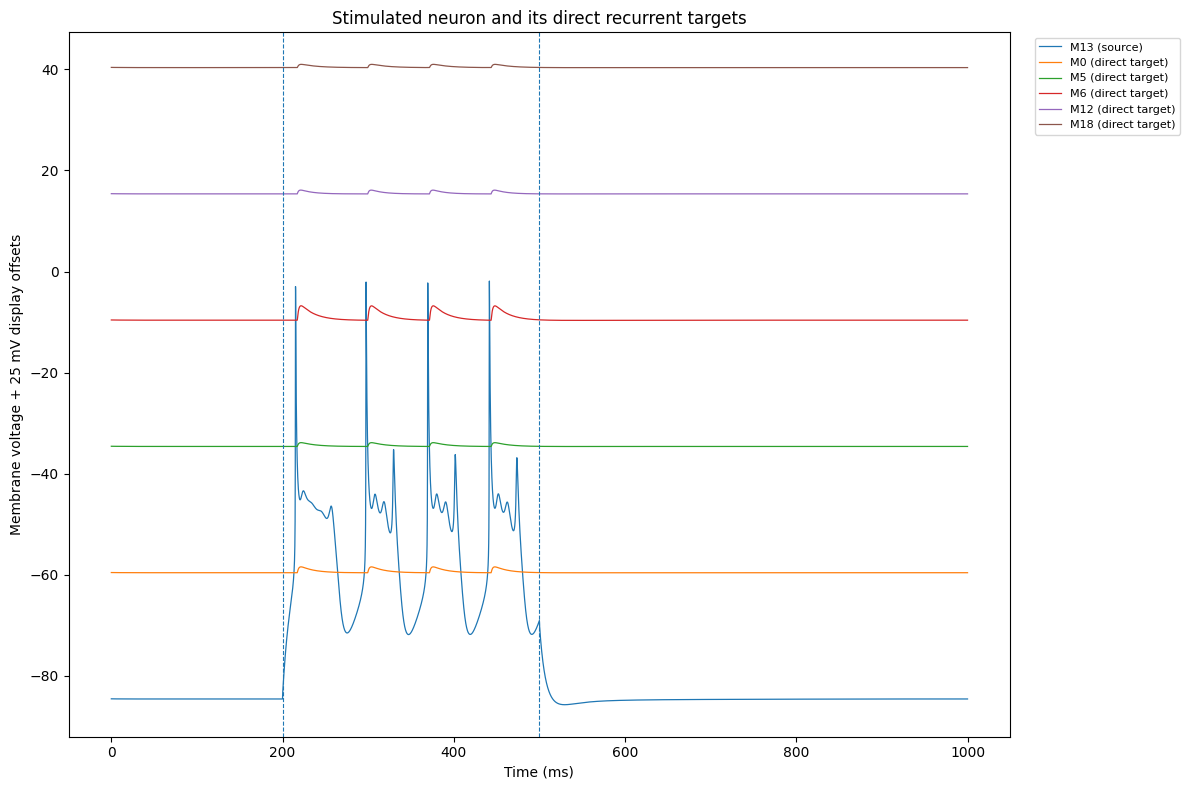

In [13]:
plot_source_and_target_voltage(run_info)
